# Exploration des fichiers ClimateNet
Ce notebook explore la structure, les variables et la distribution des classes dans les fichiers NetCDF de ClimateNet.

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import glob
import gc
from tqdm import tqdm

In [3]:
FILE_PATH = '../../climatenet/train/data-1996-06-09-01-1_0.nc'  # data/climatenet/train/data-1996-06-09-01-1_0.nc

ds = xr.open_dataset(FILE_PATH)

print('STRUCTURE DU FICHIER')
print(ds)
print()
print('DIMENSIONS')
print(dict(ds.dims))
print()
print('VARIABLES')
for var in ds.data_vars:
    print(f'  {var}: shape={ds[var].shape}, dtype={ds[var].dtype}')

STRUCTURE DU FICHIER
<xarray.Dataset> Size: 64MB
Dimensions:  (time: 1, lat: 768, lon: 1152)
Coordinates:
  * time     (time) <U23 92B 'data-1996-06-09-01-1.nc'
  * lat      (lat) float64 6kB -90.0 -89.77 -89.53 -89.3 ... 89.53 89.77 90.0
  * lon      (lon) float64 9kB 0.0 0.3125 0.625 0.9375 ... 359.1 359.4 359.7
Data variables: (12/17)
    TMQ      (time, lat, lon) float32 4MB ...
    U850     (time, lat, lon) float32 4MB ...
    V850     (time, lat, lon) float32 4MB ...
    UBOT     (time, lat, lon) float32 4MB ...
    VBOT     (time, lat, lon) float32 4MB ...
    QREFHT   (time, lat, lon) float32 4MB ...
    ...       ...
    TS       (time, lat, lon) float32 4MB ...
    TREFHT   (time, lat, lon) float32 4MB ...
    Z1000    (time, lat, lon) float32 4MB ...
    Z200     (time, lat, lon) float32 4MB ...
    ZBOT     (time, lat, lon) float32 4MB ...
    LABELS   (lat, lon) int64 7MB ...

DIMENSIONS
{'time': 1, 'lat': 768, 'lon': 1152}

VARIABLES
  TMQ: shape=(1, 768, 1152), dtype=flo

/var/folders/xk/vbrlq_ms0f36v65nyhxw_c_h0000gn/T/ipykernel_1966/19915331.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(dict(ds.dims))


## Exploration des labels (LABELS)

In [4]:
labels = ds['LABELS'].values

print(f'Shape des labels : {labels.shape}')
print(f'Valeurs uniques  : {np.unique(labels)}')
print()

total = labels.size
for cls, name in [(0, 'BG'), (1, 'TC'), (2, 'AR')]:
    count = np.sum(labels == cls)
    print(f'Classe {cls} ({name}): {count} pixels ({100*count/total:.2f}%)')

Shape des labels : (768, 1152)
Valeurs uniques  : [0 1 2]

Classe 0 (BG): 817294 pixels (92.38%)
Classe 1 (TC): 3750 pixels (0.42%)
Classe 2 (AR): 63692 pixels (7.20%)


In [5]:
TRAIN_DIR = '../../climatenet/train/'
TOTAL_PIXELS = 768 * 1152 

files = sorted(glob.glob(f'{TRAIN_DIR}*.nc'))
print(f'Nombre de fichiers train trouvés : {len(files)}')

Nombre de fichiers train trouvés : 398


In [6]:
records = []
 
for file in files:
    data = xr.open_dataset(file)
    labels = data['LABELS'].values.flatten()
    data.close()
 
    n_bg = int(np.sum(labels == 0))
    n_tc = int(np.sum(labels == 1))
    n_ar = int(np.sum(labels == 2))
 
    records.append({
        'filename': Path(file).name,
        'n_bg': n_bg,
        'n_tc': n_tc,
        'n_ar': n_ar,
        'pct_bg': 100 * n_bg / TOTAL_PIXELS,
        'pct_tc': 100 * n_tc / TOTAL_PIXELS,
        'pct_ar': 100 * n_ar / TOTAL_PIXELS,
        'has_tc': n_tc > 0,
        'has_ar': n_ar > 0,
        'has_both': (n_tc > 0) and (n_ar > 0),
        'only_bg': (n_tc == 0) and (n_ar == 0),
    })
 
df = pd.DataFrame(records)
df.to_csv('../distribution_csv_files/train_class_distribution.csv', index=False)
print(f'{len(df)} fichiers traités')

398 fichiers traités


In [7]:
print('RÉSUMÉ GLOBAL')
print('-' * 55)
print(f"Total fichiers: {len(df)}")
print(f"Fichiers SANS TC ni AR: {df['only_bg'].sum()}  ({100*df['only_bg'].mean():.1f}%)")
print(f"Fichiers avec TC: {df['has_tc'].sum()}  ({100*df['has_tc'].mean():.1f}%)")
print(f"Fichiers avec AR: {df['has_ar'].sum()}  ({100*df['has_ar'].mean():.1f}%)")
print(f"Fichiers avec TC ET AR: {df['has_both'].sum()}  ({100*df['has_both'].mean():.1f}%)")
 
print()
print('TOTAUX PIXELS (tous fichiers confondus)')
print('-' * 55)
total_bg = df['n_bg'].sum()
total_tc = df['n_tc'].sum()
total_ar = df['n_ar'].sum()

grand_total = total_bg + total_tc + total_ar

print(f"BG: {total_bg}  ({100*total_bg/grand_total:.3f}%)")
print(f"TC: {total_tc}  ({100*total_tc/grand_total:.3f}%)")
print(f"AR: {total_ar}  ({100*total_ar/grand_total:.3f}%)")
print(f"\nRatio BG / TC: {total_bg/max(total_tc,1):>8.0f}x")
print(f"Ratio BG / AR: {total_bg/max(total_ar,1):>8.0f}x")

RÉSUMÉ GLOBAL
-------------------------------------------------------
Total fichiers: 398
Fichiers SANS TC ni AR: 0  (0.0%)
Fichiers avec TC: 331  (83.2%)
Fichiers avec AR: 397  (99.7%)
Fichiers avec TC ET AR: 330  (82.9%)

TOTAUX PIXELS (tous fichiers confondus)
-------------------------------------------------------
BG: 330520699  (93.865%)
TC: 1626347  (0.462%)
AR: 19977882  (5.674%)

Ratio BG / TC:      203x
Ratio BG / AR:       17x


In [8]:
SHAPE = (768, 1152)  # lat × lon

count_tc = np.zeros(SHAPE, dtype=np.int32)
count_ar = np.zeros(SHAPE, dtype=np.int32)
count_bg = np.zeros(SHAPE, dtype=np.int32)

In [1]:
# Calcul des count
for f in tqdm(files, desc='Accumulation des labels'):
    ds = xr.open_dataset(f)
    labels = ds['LABELS'].values  # shape (768, 1152)
    ds.close()
 
    count_tc += (labels == 1).astype(np.int32)
    count_ar += (labels == 2).astype(np.int32)
    count_bg += (labels == 0).astype(np.int32)
  
# Sauvegarde pour réutilisation
np.save('../npy_files/count_tc.npy', count_tc)
np.save('../npy_files/count_ar.npy', count_ar)
np.save('../npy_files/count_bg.npy', count_bg)
print('Matrices sauvegardées (count_tc.npy, count_ar.npy, count_bg.npy)')

NameError: name 'tqdm' is not defined

In [ ]:
# Analyse des Zones

count_tc = np.load('../npy_files/count_tc.npy')
count_ar = np.load('../npy_files/count_ar.npy')
count_bg = np.load('../npy_files/count_bg.npy')

never_tc = count_tc == 0
never_ar = count_ar == 0
never_event = never_tc & never_ar
always_bg = count_bg == len(files)
 
total_pixels = SHAPE[0] * SHAPE[1]
 
print()
print('ANALYSE DES ZONES PERMANENTES')
print('-' * 55)
print(f'Total pixels par grille    : {total_pixels:>10,}')
print(f'Jamais TC (sur {len(files)} fichiers)  : {never_tc.sum():>10,}  ({100*never_tc.mean():.1f}%)')
print(f'Jamais AR (sur {len(files)} fichiers)  : {never_ar.sum():>10,}  ({100*never_ar.mean():.1f}%)')
print(f'Toujours BG                : {always_bg.sum():>10,}  ({100*always_bg.mean():.1f}%)')
print()




ANALYSE DES ZONES PERMANENTES
-------------------------------------------------------
Total pixels par grille    :    884,736
Jamais TC (sur 398 fichiers)  :    632,388  (71.5%)
Jamais AR (sur 398 fichiers)  :    269,588  (30.5%)
Toujours BG                :    247,154  (27.9%)

Pixel le plus souvent TC   : 65 fois / 398 fichiers (16.3%)
Pixel le plus souvent AR   : 165 fois / 398 fichiers (41.5%)


## Masque potentiel

En ignorant les zones jamais actives:
- On peut ignorer 27.9% des pixels de BG

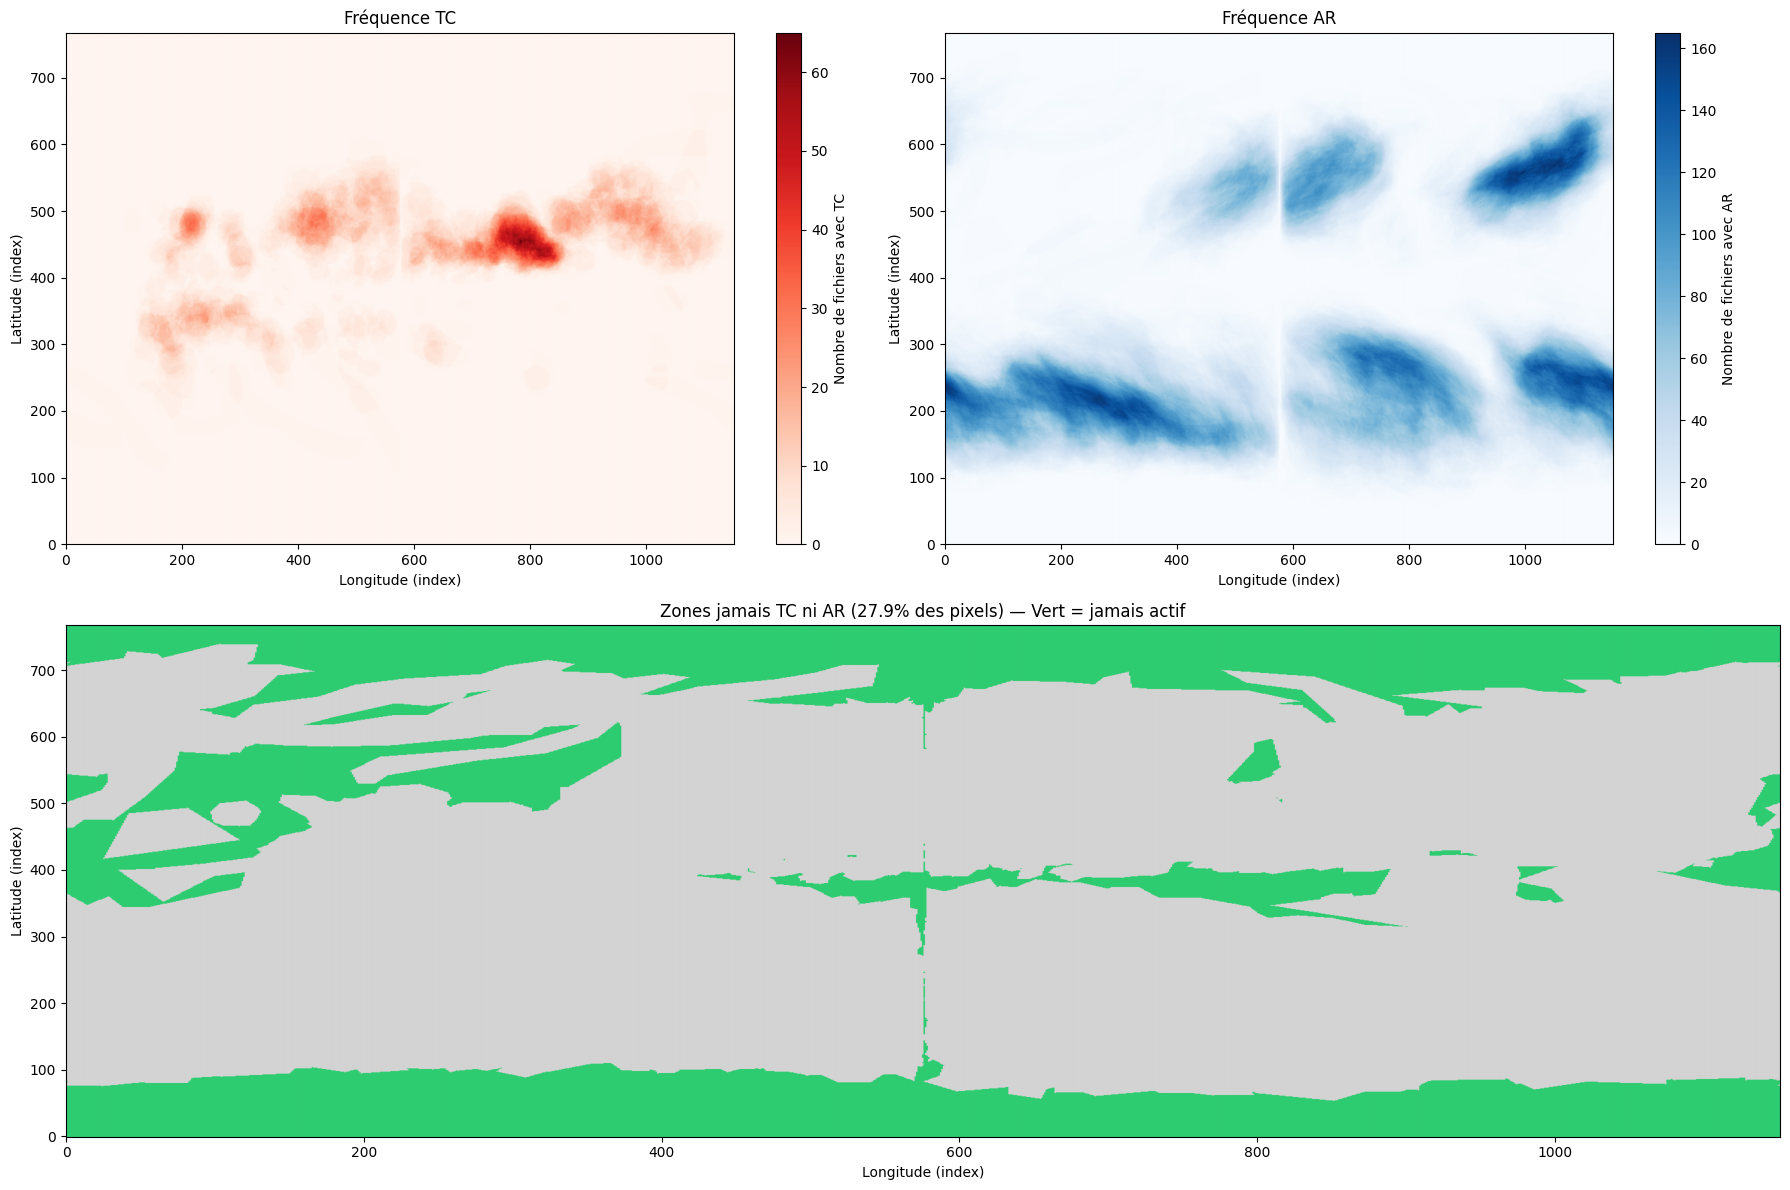

In [12]:
fig = plt.figure(figsize=(18, 12))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 1, 2)

# Fréquence TC
im1 = ax1.imshow(count_tc, origin='lower', cmap='Reds', aspect='auto')
plt.colorbar(im1, ax=ax1, label='Nombre de fichiers avec TC')
ax1.set_title('Fréquence TC')
ax1.set_xlabel('Longitude (index)')
ax1.set_ylabel('Latitude (index)')

# Fréquence AR
im2 = ax2.imshow(count_ar, origin='lower', cmap='Blues', aspect='auto')
plt.colorbar(im2, ax=ax2, label='Nombre de fichiers avec AR')
ax2.set_title('Fréquence AR')
ax2.set_xlabel('Longitude (index)')
ax2.set_ylabel('Latitude (index)')

# Zones jamais actives
cmap3 = mcolors.ListedColormap(['#d3d3d3', '#2ecc71'])
ax3.imshow(never_event.astype(int), origin='lower', cmap=cmap3, aspect='auto', vmin=0, vmax=1)
ax3.set_title(f'Zones jamais TC ni AR ({100*never_event.mean():.1f}% des pixels) — Vert = jamais actif')
ax3.set_xlabel('Longitude (index)')
ax3.set_ylabel('Latitude (index)')

plt.tight_layout()
plt.savefig('../images/geographic_zones_analysis.png', dpi=150, bbox_inches='tight')
plt.show()